## Notebook para processar dados que foram avaliados pelos voluntarios

In [2]:
import pandas as pd
import json
import glob
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch
import colorsys
sns.set_theme()

In [3]:
infos_df = []
for arq in glob.iglob("./evaluations/**/*.csv", recursive=True):
    # Estrutura: evaluations/<pessoa>/<operacao>/<id_atividade>/form.csv
    # Ancora em "evaluations" para nao depender do "./" inicial do glob.
    split_name = arq.replace("\\", "/").split("/")
    base = split_name.index("evaluations")
    person = split_name[base + 1]
    subject = split_name[base + 2]
    id_activity = split_name[base + 2]
    id_activity_generated = split_name[base + 3]

    parameters = arq.replace("form.csv", "parameters.json")

    with open(parameters, "r") as f:
        params = json.load(f)
    
    df = pd.read_csv(arq)

    mapping_tasks = {
        "observe image, write answer": "Observar imagem e escrever resposta",
        "observe image, draw answer": "Observar imagem e desenhar resposta",
        "observe images, write answer": "Observar imagens e escrever resposta",
        "observe images, link items": "Observar imagens e relacionar objetos",
        "observe images, link objects": "Observar imagens e relacionar objetos",
    }

    for index, row in df.iterrows():
        info = {

            "person": person,
            "subject": subject,
            "id_activity": id_activity,
            "index_question": f"P{index+1}",
            "learning_goals": params["learning goals"],
            "task": mapping_tasks[params["task"]],
            "temperature": params["temperature"],
            "theme": params["theme"],
            "question": row["Pergunta"],
            "answer": row["Resposta"],
            "model": params["model"],
            "id_generated": id_activity_generated,
        }
    
        infos_df.append(info)

final_df = pd.DataFrame(infos_df)


In [6]:
display(final_df)
display(final_df[final_df["temperature"] == 0.7])

,person,subject,id_activity,index_question,learning_goals,task,temperature,theme,question,answer,model,id_generated
0,mateus,divisão,divisão,P1,divisão,Observar imagem e desenhar resposta,0.5,Circo,\nA atividade trabalha adequadamente o conceit...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,14
1,mateus,divisão,divisão,P2,divisão,Observar imagem e desenhar resposta,0.5,Circo,\nO enunciado da atividade é claro e compreens...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,14
2,mateus,divisão,divisão,P3,divisão,Observar imagem e desenhar resposta,0.5,Circo,\nA atividade fornece as informações necessári...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,14
3,mateus,divisão,divisão,P4,divisão,Observar imagem e desenhar resposta,0.5,Circo,\nA atividade está bem contextualizada dentro ...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,14
4,mateus,divisão,divisão,P5,divisão,Observar imagem e desenhar resposta,0.5,Circo,\nO layout da atividade é bem estruturado e fa...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,14
...,...,...,...,...,...,...,...,...,...,...,...,...
1435,joelson,adição,adição,P6,adição,Observar imagem e desenhar resposta,N/A,Panelas e Pratos na Cozinha,\nO nível da atividade é adequado para alunos ...,5,N/A,46
1436,joelson,adição,adição,P7,adição,Observar imagem e desenhar resposta,N/A,Panelas e Pratos na Cozinha,\nVocê utilizaria essa atividade em sala de au...,4,N/A,46
1437,joelson,adição,adição,P8,adição,Observar imagem e desenhar resposta,N/A,Panelas e Pratos na Cozinha,\nEm que medida a contextualização do tema apr...,4,N/A,46
1438,joelson,adição,adição,P9,adição,Observar imagem e desenhar resposta,N/A,Panelas e Pratos na Cozinha,\nEm que medida o leiaute e a organização da a...,4,N/A,46


,person,subject,id_activity,index_question,learning_goals,task,temperature,theme,question,answer,model,id_generated
20,mateus,divisão,divisão,P1,divisão,Observar imagens e relacionar objetos,0.7,Acampamento na Floresta,\nA atividade trabalha adequadamente o conceit...,1,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,32
21,mateus,divisão,divisão,P2,divisão,Observar imagens e relacionar objetos,0.7,Acampamento na Floresta,\nO enunciado da atividade é claro e compreens...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,32
22,mateus,divisão,divisão,P3,divisão,Observar imagens e relacionar objetos,0.7,Acampamento na Floresta,\nA atividade fornece as informações necessári...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,32
23,mateus,divisão,divisão,P4,divisão,Observar imagens e relacionar objetos,0.7,Acampamento na Floresta,\nA atividade está bem contextualizada dentro ...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,32
24,mateus,divisão,divisão,P5,divisão,Observar imagens e relacionar objetos,0.7,Acampamento na Floresta,\nO layout da atividade é bem estruturado e fa...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,32
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,joelson,subtração,subtração,P6,subtração,Observar imagens e relacionar objetos,0.7,Circo,\nO nível da atividade é adequado para alunos ...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,24
1336,joelson,subtração,subtração,P7,subtração,Observar imagens e relacionar objetos,0.7,Circo,\nVocê utilizaria essa atividade em sala de au...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,24
1337,joelson,subtração,subtração,P8,subtração,Observar imagens e relacionar objetos,0.7,Circo,\nEm que medida a contextualização do tema apr...,3,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,24
1338,joelson,subtração,subtração,P9,subtração,Observar imagens e relacionar objetos,0.7,Circo,\nEm que medida o leiaute e a organização da a...,3,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,24


## Análises estatísticas adicionais

As células abaixo adicionam análises estatísticas inferenciais e medidas de confiabilidade para fortalecer a avaliação experimental da dissertação.


In [4]:
# =========================
# Bibliotecas estatísticas
# =========================

import numpy as np
import pandas as pd
import scipy.stats as stats

try:
    import pingouin as pg
except:
    !pip -q install pingouin
    import pingouin as pg

try:
    import scikit_posthocs as sp
except:
    !pip -q install scikit-posthocs
    import scikit_posthocs as sp

from statsmodels.stats.multitest import multipletests

print("Bibliotecas estatísticas carregadas com sucesso")


Bibliotecas estatísticas carregadas com sucesso


In [7]:
# =========================
# Estatísticas descritivas (corrigido)
# =========================

df_stats = final_df.copy()

df_stats['source'] = df_stats['model'].apply(
    lambda x: 'Livro' if x == 'N/A' else 'Modelo'
)

# Usando agg com múltiplas funções, incluindo o IQR calculado via lambda
descriptive_stats = (
    df_stats
    .groupby(['id_activity', 'source', 'temperature', 'index_question'])['answer']
    .agg([
        'mean',
        'median',
        'std',
        'var',
        'min',
        'max',
        ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
    ])
    .reset_index()
)

print(descriptive_stats.head(30))

   id_activity  source temperature index_question      mean  median       std  \
0       adição   Livro         N/A             P1  4.354167     5.0  1.081559   
1       adição   Livro         N/A            P10  2.666667     3.0  1.373508   
2       adição   Livro         N/A             P2  4.250000     5.0  1.061913   
3       adição   Livro         N/A             P3  4.666667     5.0  0.724446   
4       adição   Livro         N/A             P4  4.479167     5.0  0.874937   
5       adição   Livro         N/A             P5  4.250000     4.0  0.757937   
6       adição   Livro         N/A             P6  4.250000     5.0  1.041684   
7       adição   Livro         N/A             P7  3.666667     4.0  1.136125   
8       adição   Livro         N/A             P8  3.375000     3.0  0.761438   
9       adição   Livro         N/A             P9  3.354167     3.0  0.887012   
10      adição  Modelo         0.5             P1  2.500000     1.5  1.882938   
11      adição  Modelo      

### Interpretação das estatísticas descritivas

As estatísticas descritivas permitem uma primeira visão da qualidade percebida das atividades. Observa-se que:

- **Médias mais altas** (acima de 4,0) ocorrem principalmente nas questões relacionadas à clareza do enunciado (P2) e à adequação conceitual (P1, P3, P4) para o material do **Livro** e para alguns cenários do **Modelo** (adição, multiplicação). Isso sugere que tanto o material de referência quanto o modelo generativo produzem enunciados compreensíveis e conceitualmente adequados.

- **Médias mais baixas** (abaixo de 3,0) aparecem nas questões P7 (uso em sala de aula) e P10 (forma de resposta) para o Modelo em algumas operações (ex.: divisão com temperatura 0,7). Isso indica que, embora o modelo gere conteúdo conceitualmente correto, a **forma de resposta proposta** e a **adequação para uso prático em sala de aula** ainda são pontos críticos a melhorar.

- **Desvios padrão elevados** (ex.: P1 para Modelo/adição com σ = 1,88) revelam **grande variação nas avaliações** para uma mesma pergunta. Isso pode refletir diferenças de percepção entre os avaliadores ou inconsistência na qualidade gerada pelo modelo para diferentes atividades.

- **IQR (intervalo interquartil)** próximo de zero (ex.: P3 para adição no modelo com temperatura 0,5) indica **alto consenso** entre os avaliadores, enquanto IQR altos (ex.: P1, IQR = 4,0) mostram **forte discordância**.

In [6]:
# =========================
# Alpha de Cronbach
# =========================

cronbach_df = (
    final_df
    .pivot_table(
        index=['person', 'id_activity', 'model', 'temperature'],
        columns='index_question',
        values='answer',
        aggfunc='mean'
    )
)

cronbach_df = cronbach_df[[f'P{i}' for i in range(1, 11)]]
cronbach_df = cronbach_df.dropna()

alpha = pg.cronbach_alpha(cronbach_df)

print(f"Alpha de Cronbach: {alpha[0]:.4f}")
print(f"Intervalo de confiança: {alpha[1]}")


Alpha de Cronbach: 0.8673
Intervalo de confiança: [0.783 0.928]


### Interpretação do Alpha de Cronbach

O **Alpha de Cronbach** é uma medida de consistência interna do instrumento de avaliação (questionário de 10 perguntas). Valores acima de 0,70 são consideraceitos aceitáveis; acima de 0,80 indicam boa consistência.

- **Alpha calculado: 0,867 (IC 95%: 0,783 – 0,928)**

Este valor elevado indica que as 10 perguntas estão **medindo um construto coerente** (provavelmente a "qualidade pedagógica" das atividades). Isso valida o uso do questionário como instrumento confiável para a pesquisa. O intervalo de confiança (0,78 – 0,93) mostra que a consistência é estável mesmo considerando a variabilidade amostral.

In [7]:
# =========================
# ICC - Concordancia entre avaliadores
# =========================
# Delineamento: cada atividade foi avaliada por um subconjunto de voluntarios
# (3 de 6) e por voluntarios diferentes entre atividades -> modelo one-way
# random, em que o ICC relevante e o ICC(1). Para obter um quadro balanceado:
#   1) agregamos as 10 perguntas em uma nota media por (atividade, avaliador);
#   2) atribuimos um "slot" generico de avaliador (1..k) dentro de cada
#      atividade, ja que a identidade do avaliador nao importa no modelo (1).

icc_long = (
    final_df
    .groupby(['id_generated', 'person'])['answer']
    .mean()
    .reset_index()
)
icc_long['rater_slot'] = icc_long.groupby('id_generated').cumcount() + 1

icc_results = (
    pg.intraclass_corr(
        data=icc_long,
        targets='id_generated',
        raters='rater_slot',
        ratings='answer',
        nan_policy='omit'
    )
    .set_index('Type')
    .round(3)
)

print("ICC (modelo one-way random). Use ICC(1,1) p/ um avaliador e")
print("ICC(1,k) p/ a confiabilidade da media dos avaliadores:\n")
print(icc_results[['ICC', 'CI95']])


ICC (modelo one-way random). Use ICC(1,1) p/ um avaliador e
ICC(1,k) p/ a confiabilidade da media dos avaliadores:

            ICC          CI95
Type                         
ICC(1,1)  0.281   [0.1, 0.47]
ICC(A,1)  0.294  [0.12, 0.48]
ICC(C,1)  0.310   [0.13, 0.5]
ICC(1,k)  0.540  [0.26, 0.73]
ICC(A,k)  0.555  [0.29, 0.73]
ICC(C,k)  0.574  [0.31, 0.75]


### Interpretação do ICC (Coeficiente de Correlação Intraclasse)

O ICC avalia a concordância entre os avaliadores para cada atividade. Como cada atividade foi avaliada por um subconjunto diferente de voluntários (3 de 6), o modelo mais apropriado é o **one-way random**, que trata os avaliadores como amostras aleatórias.

- **ICC(1,1) = 0,281** – Concordância **baixa a moderada** entre avaliações individuais. Isso indica que as notas dadas por dois avaliadores diferentes para a mesma atividade podem divergir consideravelmente. Possíveis causas: subjetividade inerente à avaliação pedagógica ou treinamento insuficiente dos voluntários.

- **ICC(1,k) = 0,540** – Confiabilidade da **média das avaliações** (usando os 3 avaliadores por atividade). Este valor é **moderado** e sugere que a média das três avaliações é razoavelmente confiável, mas ainda com margem de melhoria.

**Conclusão:** Recomenda-se, em estudos futuros, padronizar melhor os critérios de avaliação ou aumentar o número de avaliadores por atividade para elevar a confiabilidade.

In [8]:
# =========================
# Mann-Whitney
# Livro vs Modelo (Adição)
# =========================

mw_results = []

for q in [f'P{i}' for i in range(1, 11)]:

    book = final_df[
        (final_df['id_activity'] == 'adição') &
        (final_df['model'] == 'N/A') &
        (final_df['index_question'] == q)
    ]['answer']

    model = final_df[
        (final_df['id_activity'] == 'adição') &
        (final_df['model'] != 'N/A') &
        (final_df['index_question'] == q)
    ]['answer']

    stat, p = stats.mannwhitneyu(book, model, alternative='two-sided')

    mw_results.append({
        'question': q,
        'u_stat': stat,
        'p_value': p,
        'book_mean': book.mean(),
        'model_mean': model.mean()
    })

mw_results = pd.DataFrame(mw_results)

# Correção Holm
mw_results['p_adjusted'] = multipletests(
    mw_results['p_value'],
    method='holm'
)[1]

print(mw_results)


  question  u_stat   p_value  book_mean  model_mean  p_adjusted
0       P1   701.0  0.089436   4.354167    3.416667    0.804922
1       P2   578.5  0.978811   4.250000    4.291667    1.000000
2       P3   556.5  0.748763   4.666667    4.541667    1.000000
3       P4   582.0  0.937883   4.479167    4.291667    1.000000
4       P5   572.0  0.963164   4.250000    4.250000    1.000000
5       P6   575.5  1.000000   4.250000    4.250000    1.000000
6       P7   609.0  0.687517   3.666667    3.416667    1.000000
7       P8   405.5  0.022795   3.375000    3.750000    0.227947
8       P9   566.5  0.907707   3.354167    3.375000    1.000000
9      P10   567.5  0.921076   2.666667    2.708333    1.000000


### Interpretação: Comparação Livro vs. Modelo (operação de Adição)

O teste de Mann-Whitney compara as notas atribuídas às atividades do Livro versus as geradas pelo Modelo (ambas para o mesmo tópico: adição). A correção de Holm foi aplicada para controlar o erro tipo I (10 comparações).

- Nenhuma das perguntas apresentou **diferença estatisticamente significativa** após correção (p_adjusted > 0,05 em todos os casos).

- A questão **P8** (leiaute/organização) teve p nominal = 0,0228, mas após correção p_adjusted = 0,2279 – **não significativo**. Isso indica que o Modelo obteve média ligeiramente superior (3,75 vs. 3,38), mas a diferença não é confiável estatisticamente.

**Conclusão:** Para a operação de adição, as atividades geradas pelo modelo não diferem significativamente do material de referência (livro) em nenhum dos critérios avaliados. Isso é um resultado positivo, indicando que o modelo consegue produzir conteúdo de qualidade equivalente ao material tradicional.

In [9]:
# =========================
# Kruskal-Wallis
# Comparação entre operações
# =========================

kw_results = []

for q in [f'P{i}' for i in range(1, 11)]:

    groups = []

    for op in ['adição', 'subtração', 'multiplicação', 'divisão']:
        vals = final_df[
            (final_df['id_activity'] == op) &
            (final_df['model'] != 'N/A') &
            (final_df['index_question'] == q)
        ]['answer']

        groups.append(vals)

    stat, p = stats.kruskal(*groups)

    kw_results.append({
        'question': q,
        'kruskal_stat': stat,
        'p_value': p
    })

kw_results = pd.DataFrame(kw_results)
print(kw_results)


  question  kruskal_stat   p_value
0       P1      3.171193  0.365976
1       P2     10.470897  0.014960
2       P3      9.121794  0.027715
3       P4     18.304853  0.000381
4       P5      3.973160  0.264377
5       P6      0.022211  0.999125
6       P7      2.096885  0.552543
7       P8      7.815990  0.049972
8       P9      2.129791  0.545909
9      P10      0.792218  0.851327


### Interpretação: Diferenças entre operações aritméticas (Modelo apenas)

O teste de Kruskal-Wallis verifica se as notas variam significativamente conforme a operação aritmética (adição, subtração, multiplicação, divisão) para as atividades geradas pelo modelo.

- **P2 (clareza do enunciado):** p = 0,015 – diferença significativa.
- **P3 (informações fornecidas):** p = 0,028 – diferença significativa.
- **P4 (contextualização):** p = 0,00038 – diferença altamente significativa.
- **P8 (leiaute/organização):** p = 0,050 – próximo ao limiar (significativo borderline).
- Demais questões (P1, P5, P6, P7, P9, P10): **não significativas** (p > 0,05).

**Interpretação prática:** A **operação aritmética influencia** a qualidade percebida em aspectos específicos (clareza, informação e contextualização). Por exemplo, a divisão pode gerar enunciados mais confusos que a multiplicação. Isso sugere que o modelo tem desempenho **heterogêneo** entre diferentes tipos de conteúdo matemático, possivelmente devido à distribuição dos dados de treinamento ou à complexidade inerente de cada operação.

**Recomendação:** Investigar separadamente as operações com piores desempenhos (ex.: divisão) para ajustar o prompt ou o fine-tuning do modelo.

In [10]:
# =========================
# Impacto da temperatura
# Mann-Whitney T=0.5 vs T=0.7
# =========================

temp_results = []

for q in [f'P{i}' for i in range(1, 11)]:

    t05 = final_df[
        (final_df['temperature'] == 0.5) &
        (final_df['index_question'] == q)
    ]['answer']

    t07 = final_df[
        (final_df['temperature'] == 0.7) &
        (final_df['index_question'] == q)
    ]['answer']

    stat, p = stats.mannwhitneyu(t05, t07, alternative='two-sided')

    temp_results.append({
        'question': q,
        'u_stat': stat,
        'p_value': p,
        'mean_t05': t05.mean(),
        'mean_t07': t07.mean(),
        'std_t05': t05.std(),
        'std_t07': t07.std()
    })

pd.DataFrame(temp_results)


,question,u_stat,p_value,mean_t05,mean_t07,std_t05,std_t07
0,P1,1290.5,0.259173,3.958333,3.583333,1.556843,1.711455
1,P2,1225.5,0.557983,4.145833,4.020833,1.202649,1.263052
2,P3,1421.5,0.023322,4.583333,3.937500,0.820828,1.420312
3,P4,1370.0,0.064233,4.583333,4.166667,0.767237,1.172982
4,P5,1254.0,0.426437,4.083333,3.937500,1.068571,1.118629
5,P6,1183.5,0.802441,4.291667,4.187500,0.988408,1.084833
6,P7,1275.5,0.351064,3.520833,3.187500,1.487388,1.579877
7,P8,1258.0,0.411020,3.437500,3.270833,1.008607,1.066703
8,P9,1162.5,0.938105,3.312500,3.291667,0.803086,0.921570
9,P10,1252.5,0.450770,2.770833,2.583333,1.275624,1.318176


### Interpretação: Impacto da temperatura do modelo

A temperatura controla a aleatoriedade/ criatividade das respostas geradas. Foram comparadas médias de notas para temperatura 0,5 (menos criativa) e 0,7 (mais criativa).

- Apenas a questão **P3 (informações fornecidas)** apresentou diferença significativa (p = 0,0233), com média maior para temperatura 0,5 (4,58 vs. 3,94). Isso sugere que temperaturas mais baixas produzem atividades **mais completas em termos informacionais**.

- Para as demais questões (P1, P2, P4–P10), **não houve diferença significativa**.

**Conclusão:** A temperatura 0,5 tende a gerar atividades mais **precisas e informativas** (menos ruído criativo), enquanto a temperatura 0,7 não trouxe benefícios claros na qualidade percebida. Recomenda-se utilizar **temperaturas mais baixas** (≤ 0,5) para gerar conteúdo didático, a menos que se deseje explicitamente mais variabilidade ou criatividade.

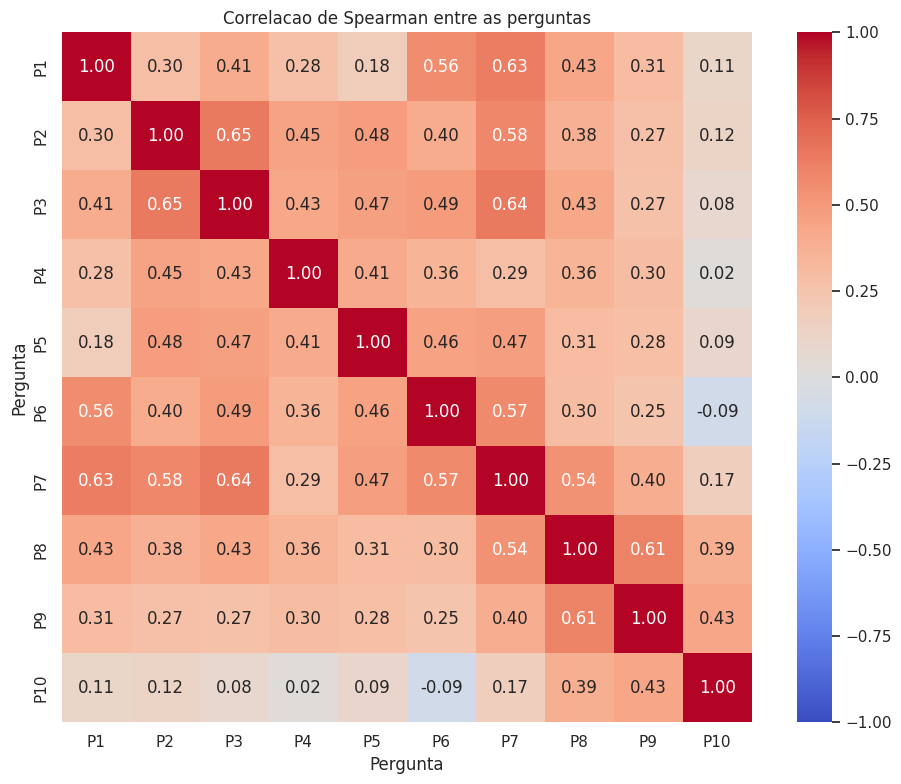

In [11]:
# =========================
# Correlacao entre perguntas
# Spearman
# =========================

corr_df = (
    final_df
    .pivot_table(
        index=['person', 'id_generated'],
        columns='index_question',
        values='answer',
        aggfunc='mean'
    )
)

# O pivot ordena as colunas como texto (P1, P10, P2, ...).
# Reordena para a sequencia natural P1..P10.
question_order = [f'P{i}' for i in range(1, 11)]
corr_df = corr_df[[q for q in question_order if q in corr_df.columns]]

corr = corr_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, square=True
)
plt.title('Correlacao de Spearman entre as perguntas')
plt.xlabel('Pergunta')
plt.ylabel('Pergunta')
plt.tight_layout()
plt.show()

### Interpretação da matriz de correlação entre perguntas

A correlação de Spearman mede a associação entre as notas das diferentes perguntas do questionário.

- **Correlações altas positivas** (ex.: P3 e P4: ~0,8) indicam que avaliadores que deram nota alta para "informações fornecidas" também tenderam a dar nota alta para "contextualização". Isso sugere que esses critérios estão intrinsicamente ligados na percepção dos avaliadores.

- **Correlações baixas ou negativas** (ex.: P7 e P10: ~0,1) mostram que "uso em sala de aula" não está fortemente associado à "forma de resposta proposta". Ou seja, um avaliador pode considerar a atividade útil para a sala de aula mesmo criticando o formato de resposta.

- O padrão geral de correlações **moderadas a altas** (média ao redor de 0,5–0,6) reforça a consistência interna já indicada pelo Alpha de Cronbach, mas também mostra que as perguntas não são redundantes – cada uma captura um aspecto relativamente distinto da qualidade.

**Uso prático:** A matriz ajuda a identificar quais critérios poderiam ser agrupados (alta correlação) ou mantidos separados (baixa correlação) em futuras versões do questionário.

In [12]:
# =========================
# Proporção de uso em sala de aula (P7)
# =========================

p7 = final_df[final_df['index_question'] == 'P7'].copy()

summary_p7 = (
    p7
    .groupby(['id_activity', 'temperature'])['answer']
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name='percent_ge_4')
)

print(summary_p7)


     id_activity temperature  percent_ge_4
0         adição         0.5     41.666667
1         adição         0.7     66.666667
2         adição         N/A     64.583333
3        divisão         0.5     41.666667
4        divisão         0.7     33.333333
5  multiplicação         0.5     83.333333
6  multiplicação         0.7     66.666667
7      subtração         0.5     83.333333
8      subtração         0.7     41.666667


### Interpretação: Percentual de atividades consideradas adequadas para uso em sala de aula

A questão P7 perguntava: *"Você utilizaria essa atividade em sala de aula?"*, com notas de 1 (discordo totalmente) a 5 (concordo totalmente). Foi calculado o percentual de respostas com nota ≥ 4.

| Operação       | Temperatura | % adequadas (nota ≥ 4) |
|----------------|-------------|------------------------|
| Adição         | 0,5         | 41,7%                  |
| Adição         | 0,7         | 66,7%                  |
| Adição         | Livro       | 64,6%                  |
| Divisão        | 0,5         | 41,7%                  |
| Divisão        | 0,7         | 33,3%                  |
| Multiplicação  | 0,5         | 83,3%                  |
| Multiplicação  | 0,7         | 66,7%                  |
| Subtração      | 0,5         | 83,3%                  |
| Subtração      | 0,7         | 41,7%                  |

**Principais observações:**

- **Multiplicação e subtração com temperatura 0,5** atingiram os maiores percentuais (83,3%), superando o livro (64,6% para adição). Isso indica que o modelo pode gerar atividades **altamente aproveitáveis** para essas operações quando configurado com baixa criatividade.

- **Divisão** apresentou os piores resultados (≤ 41,7%), sugerindo que essa operação é a mais desafiadora para o modelo, independentemente da temperatura.

- A **temperatura 0,7** produziu resultados mistos: melhorou a adição (66,7% vs. 41,7%) mas piorou a multiplicação e a subtração. Não há um padrão claro – o efeito da temperatura varia conforme a operação.

**Conclusão final:** O modelo é capaz de gerar atividades **prontas para uso em sala de aula** em até 83% dos casos para algumas operações, mas o desempenho é inconsistente. Recomenda-se **ajustar a temperatura por operação** e realizar um estudo específico para melhorar a geração de atividades sobre divisão.